# ML Fundamentals #6: K-Nearest Neighbors (KNN)

## Spotify Track Popularity Classification

This project implements a K-Nearest Neighbors classifier using Spotify track audio features.

The original Spotify popularity score is transformed into popularity categories, allowing KNN classification to be used to examine whether characteristics such as danceability, energy, acousticness, valence, tempo, and other audio features can distinguish different levels of track popularity.

The notebook covers:

- Data Loading
- Dataset Understanding
- Exploratory Data Analysis
- Popularity Class Construction
- Data Preprocessing
- Feature Scaling
- KNN Model Training
- Model Evaluation
- K-Value Analysis
- Neighbor and Distance Analysis
- Hyperparameter Tuning
- Model Serialization# ML Fundamentals #6: K-Nearest Neighbors (KNN)

## Spotify Track Popularity Classification

This project implements a K-Nearest Neighbors classifier using Spotify track audio features.

The original Spotify popularity score is transformed into popularity categories, allowing KNN classification to be used to examine whether characteristics such as danceability, energy, acousticness, valence, tempo, and other audio features can distinguish different levels of track popularity.

The notebook covers:

- Data Loading
- Dataset Understanding
- Exploratory Data Analysis
- Popularity Class Construction
- Data Preprocessing
- Feature Scaling
- KNN Model Training
- Model Evaluation
- K-Value Analysis
- Neighbor and Distance Analysis
- Hyperparameter Tuning
- Model Serialization

In [2]:
# Import libraries for data analysis, visualization, preprocessing, KNN modeling, and evaluation

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

In [3]:
# Create directories for datasets, models, figures, and tables

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

print("Project directories ready.")

Project directories ready.


## 2. Loading the Dataset

This project uses the Spotify Tracks Dataset, a large music dataset containing track metadata, Spotify popularity scores, genre information, and numerical audio characteristics.

The dataset contains approximately 114,000 tracks spanning 114 genres.

The original `popularity` variable ranges from 0 to 100. Popularity categories will be constructed later to formulate the problem as a K-Nearest Neighbors classification task.

In [4]:
# Load the Spotify Tracks dataset from an online CSV source

dataset_url = "https://github.com/yash-khandelwal-dev/spotify-audio-analysis/releases/download/Dataset/spotify.csv"

df = pd.read_csv(dataset_url)

df.head()

,track_genre_acoustic,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,...,key_cos,duration_log,duration_log_z,time_signature_class_boolean,loudness_yeo,is_instrumental,is_dance_hit,temp_zscore,track_genre,track_genre_le
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.866025,1.577830,0.186048,1.0,0.132593,0.0,0.0,-1.141849,acoustic,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.866025,1.250904,-0.942392,1.0,-1.658038,0.0,0.0,-1.489701,acoustic,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,1.507132,-0.057979,1.0,-0.538749,0.0,0.0,-1.528296,acoustic,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,1.473744,-0.173222,1.0,-1.803951,0.0,0.0,1.987849,acoustic,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.500000,1.461916,-0.214050,1.0,-0.528464,0.0,0.0,-0.073343,acoustic,0.0


In [5]:
# Display the dataset dimensions and available columns

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

Rows: 113999
Columns: 159

Columns:
['track_genre_acoustic', 'track_genre_afrobeat', 'track_genre_alt-rock', 'track_genre_alternative', 'track_genre_ambient', 'track_genre_anime', 'track_genre_black-metal', 'track_genre_bluegrass', 'track_genre_blues', 'track_genre_brazil', 'track_genre_breakbeat', 'track_genre_british', 'track_genre_cantopop', 'track_genre_chicago-house', 'track_genre_children', 'track_genre_chill', 'track_genre_classical', 'track_genre_club', 'track_genre_comedy', 'track_genre_country', 'track_genre_dance', 'track_genre_dancehall', 'track_genre_death-metal', 'track_genre_deep-house', 'track_genre_detroit-techno', 'track_genre_disco', 'track_genre_disney', 'track_genre_drum-and-bass', 'track_genre_dub', 'track_genre_dubstep', 'track_genre_edm', 'track_genre_electro', 'track_genre_electronic', 'track_genre_emo', 'track_genre_folk', 'track_genre_forro', 'track_genre_french', 'track_genre_funk', 'track_genre_garage', 'track_genre_german', 'track_genre_gospel', 'track_gen

In [6]:
# Save the raw dataset locally and export a preview table

df.to_csv(
    "data/raw/spotify_tracks.csv",
    index=False
)

df.head(10).to_csv(
    "outputs/tables/dataset_preview.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


### Dataset Loading Insights

- The dataset contains approximately 114,000 Spotify tracks.
- Each observation represents an individual music track.
- The dataset combines track metadata with numerical audio characteristics.
- Spotify popularity is represented by a score ranging from 0 to 100.
- The continuous popularity score will later be transformed into popularity categories for KNN classification.
- A local copy of the raw dataset has been stored to make subsequent analysis reproducible.

## 3. Understanding the Dataset

Before constructing popularity classes and training the KNN classifier, the dataset is examined to understand its structure, feature types, descriptive statistics, missing values, duplicate records, and popularity distribution.

In [7]:
# Examine dataset structure, feature types, and non-null observations

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113999 entries, 0 to 113998
Columns: 159 entries, track_genre_acoustic to track_genre_le
dtypes: float64(158), str(1)
memory usage: 138.3 MB


In [8]:
# Generate descriptive statistics for the numerical Spotify features

dataset_summary = df.describe().T

dataset_summary

,count,mean,std,min,25%,50%,75%,max
track_genre_acoustic,113999.0,8.772007e-03,0.093248,0.000000,0.00000,0.000000,0.000000,1.000000
track_genre_afrobeat,113999.0,8.772007e-03,0.093248,0.000000,0.00000,0.000000,0.000000,1.000000
track_genre_alt-rock,113999.0,8.772007e-03,0.093248,0.000000,0.00000,0.000000,0.000000,1.000000
track_genre_alternative,113999.0,8.772007e-03,0.093248,0.000000,0.00000,0.000000,0.000000,1.000000
track_genre_ambient,113999.0,8.772007e-03,0.093248,0.000000,0.00000,0.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...
loudness_yeo,113999.0,-2.393428e-17,1.000004,-3.914959,-0.59212,0.065769,0.647973,28.711253
is_instrumental,113999.0,1.125975e-01,0.316102,0.000000,0.00000,0.000000,0.000000,1.000000
is_dance_hit,113999.0,2.017562e-03,0.044872,0.000000,0.00000,0.000000,0.000000,1.000000
temp_zscore,113999.0,4.567459e-16,1.000000,-4.074538,-0.76486,-0.004360,0.597876,4.043737


In [9]:
# Save descriptive statistics for later reference

dataset_summary.to_csv(
    "outputs/tables/dataset_summary.csv"
)

In [10]:
# Examine missing values across all dataset columns

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values

,Missing Values,Missing Percentage
track_genre_acoustic,0,0.0
track_genre_afrobeat,0,0.0
track_genre_alt-rock,0,0.0
track_genre_alternative,0,0.0
track_genre_ambient,0,0.0
...,...,...
is_instrumental,0,0.0
is_dance_hit,0,0.0
temp_zscore,0,0.0
track_genre,1,0.0


In [11]:
# Save the missing-value analysis

missing_values.to_csv(
    "outputs/tables/missing_values.csv"
)

In [12]:
# Check the dataset for duplicate track records

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 1133


In [13]:
# Examine the distribution and range of Spotify popularity scores

print("Minimum popularity:", df["popularity"].min())
print("Maximum popularity:", df["popularity"].max())
print("Mean popularity:", round(df["popularity"].mean(), 2))
print("Median popularity:", df["popularity"].median())

Minimum popularity: -1.4902054888413832
Maximum popularity: 2.993122109473847
Mean popularity: -0.0
Median popularity: 0.0789591705689475


In [14]:
# Save the frequency distribution of the original popularity scores

popularity_distribution = (
    df["popularity"]
    .value_counts()
    .sort_index()
    .rename_axis("Popularity")
    .reset_index(name="Track Count")
)

popularity_distribution.to_csv(
    "outputs/tables/popularity_distribution.csv",
    index=False
)

popularity_distribution.head()

,Popularity,Track Count
0,-1.490205,16019
1,-1.445372,2140
2,-1.400539,1036
3,-1.355706,585
4,-1.310872,389


### Dataset Understanding Insights

- The dataset contains track metadata together with numerical Spotify audio features.
- The `popularity` attribute is a numerical score rather than a predefined classification label.
- Audio characteristics such as danceability, energy, loudness, acousticness, instrumentalness, valence, and tempo provide potential predictors for popularity classification.
- Missing values and duplicate records are examined before preprocessing to ensure data quality.
- The original popularity score is retained at this stage without modification.
- Popularity categories will be explicitly constructed in the preprocessing stage to formulate the KNN classification problem.

## 4. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand Spotify track popularity and examine how different audio characteristics are distributed across the dataset.

The analysis focuses on popularity scores, major numerical audio features, feature relationships, and genre representation before constructing the popularity classes used by the KNN classifier.

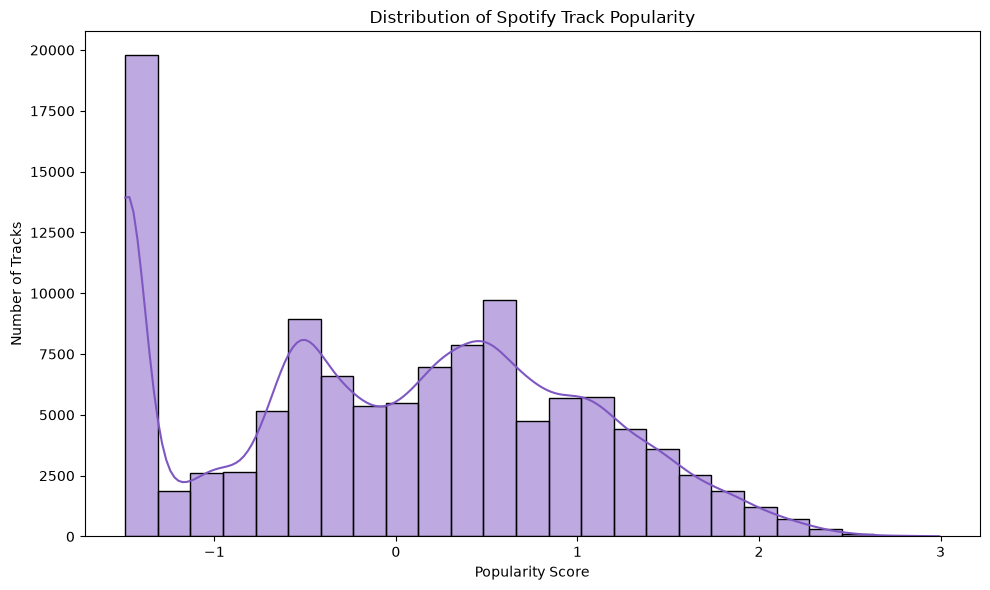

In [15]:
# Visualize the distribution of Spotify popularity scores

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="popularity",
    bins=25,
    kde=True,
    color="#7E57C2"
)

plt.title("Distribution of Spotify Track Popularity")
plt.xlabel("Popularity Score")
plt.ylabel("Number of Tracks")

plt.tight_layout()
plt.savefig("outputs/figures/popularity_distribution.png", dpi=300)
plt.show()

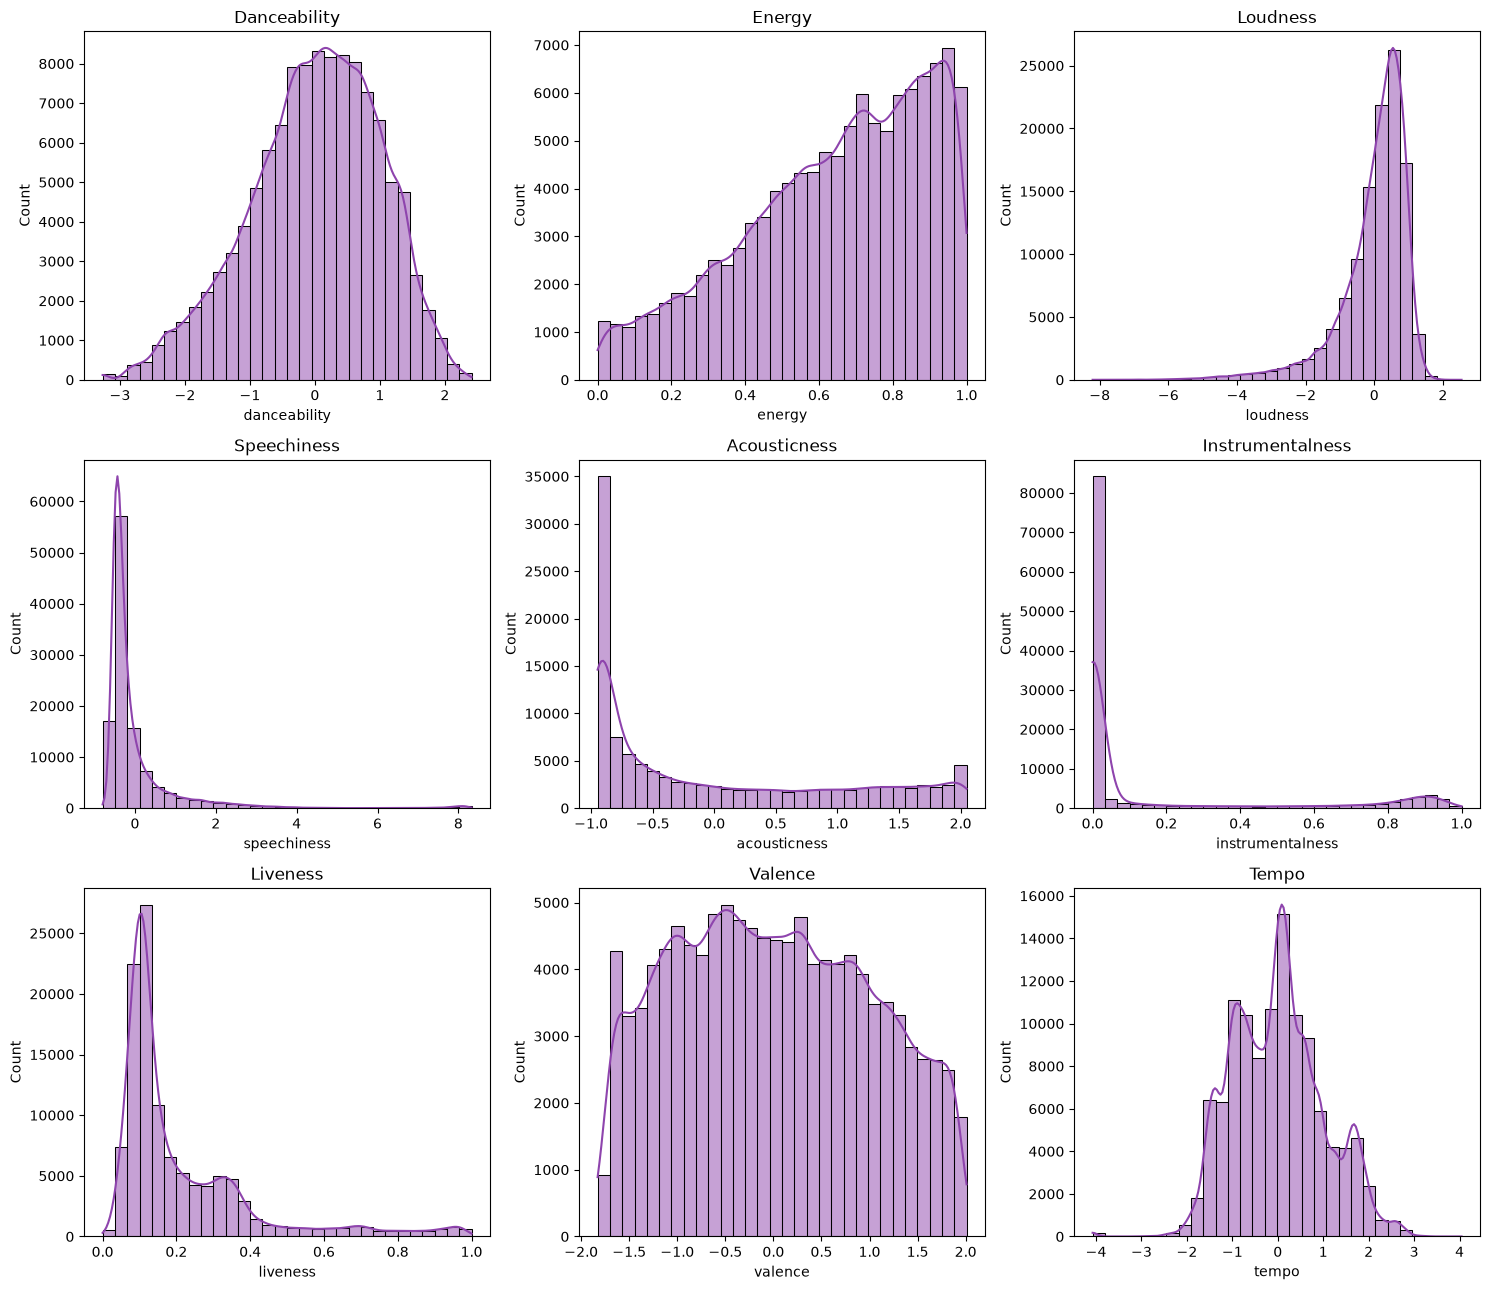

In [16]:
# Visualize distributions of major Spotify audio features

audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    sns.histplot(
        df[feature],
        bins=30,
        kde=True,
        color="#8E44AD",
        ax=axes[i]
    )
    axes[i].set_title(feature.replace("_", " ").title())

plt.tight_layout()
plt.savefig("outputs/figures/audio_feature_distributions.png", dpi=300)
plt.show()

In [17]:
# Calculate correlations among numerical Spotify attributes

numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

correlation_matrix.to_csv(
    "outputs/tables/correlation_matrix.csv"
)

correlation_matrix.round(2)

,track_genre_acoustic,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,...,key_sin,key_cos,duration_log,duration_log_z,time_signature_class_boolean,loudness_yeo,is_instrumental,is_dance_hit,temp_zscore,track_genre_le
track_genre_acoustic,1.00,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,...,0.00,0.00,-0.01,-0.01,0.00,-0.03,-0.03,-0.00,-0.01,-0.16
track_genre_afrobeat,-0.01,1.00,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,...,-0.00,-0.01,0.02,0.02,0.00,-0.00,0.02,0.01,-0.01,-0.16
track_genre_alt-rock,-0.01,-0.01,1.00,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,...,-0.01,-0.00,0.02,0.02,0.01,0.04,-0.03,-0.00,0.01,-0.16
track_genre_alternative,-0.01,-0.01,-0.01,1.00,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,...,-0.00,0.00,0.00,0.00,0.01,0.04,-0.03,-0.00,0.00,-0.15
track_genre_ambient,-0.01,-0.01,-0.01,-0.01,1.00,-0.01,-0.01,-0.01,-0.01,-0.01,...,0.01,-0.00,0.00,0.00,-0.04,-0.15,0.16,-0.00,-0.03,-0.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
loudness_yeo,-0.03,-0.00,0.04,0.04,-0.15,0.02,0.03,-0.05,-0.01,0.00,...,-0.03,-0.01,0.03,0.03,0.12,1.00,-0.35,0.04,0.22,-0.04
is_instrumental,-0.03,0.02,-0.03,-0.03,0.16,0.04,0.05,-0.01,-0.03,-0.03,...,0.01,0.00,0.04,0.04,-0.07,-0.35,1.00,0.02,-0.06,-0.05
is_dance_hit,-0.00,0.01,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,...,-0.01,0.00,0.02,0.02,0.00,0.04,0.02,1.00,0.00,-0.02
temp_zscore,-0.01,-0.01,0.01,0.00,-0.03,0.00,0.02,0.01,-0.02,-0.00,...,-0.02,-0.00,0.04,0.04,0.09,0.22,-0.06,0.00,1.00,-0.03


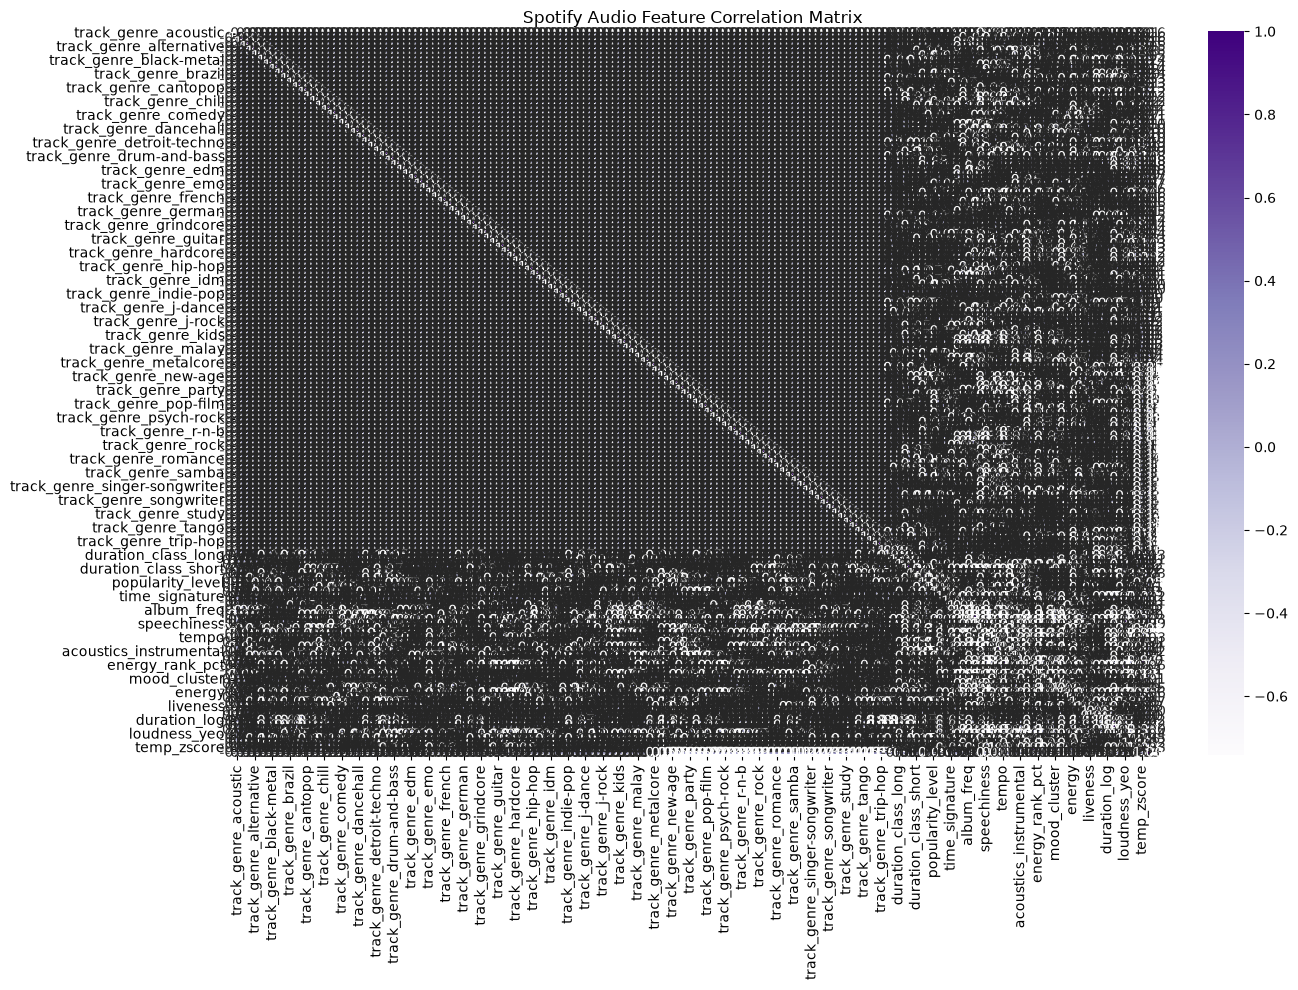

In [18]:
# Visualize correlations among numerical Spotify features

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="Purples",
    annot=True,
    fmt=".2f",
    linewidths=0.3
)

plt.title("Spotify Audio Feature Correlation Matrix")

plt.tight_layout()
plt.savefig("outputs/figures/correlation_heatmap.png", dpi=300)
plt.show()

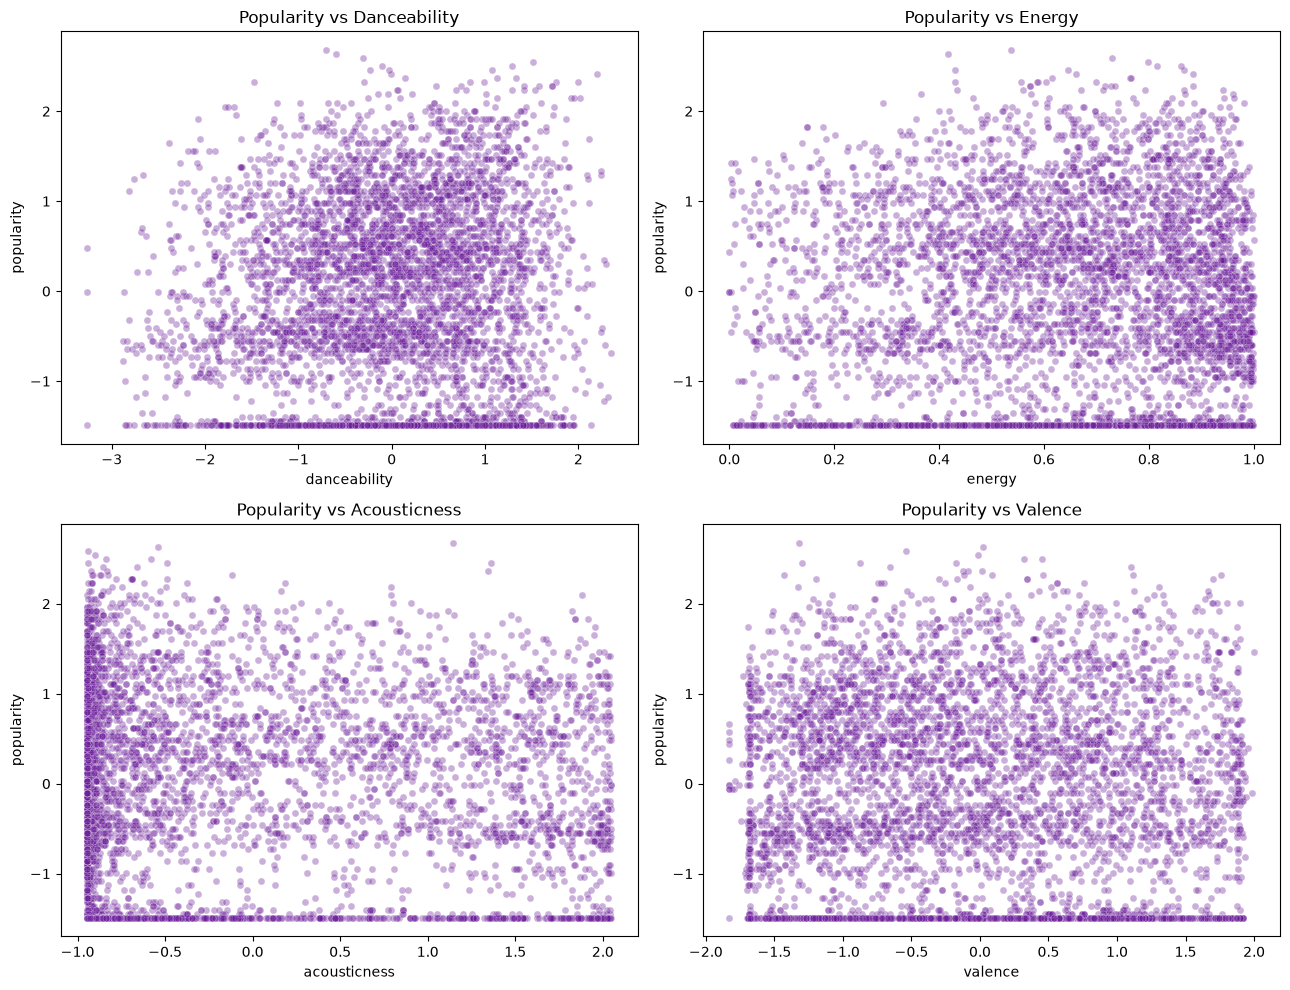

In [19]:
# Examine relationships between popularity and selected audio characteristics

selected_features = [
    "danceability",
    "energy",
    "acousticness",
    "valence"
]

sample_df = df.sample(
    n=min(5000, len(df)),
    random_state=42
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, feature in enumerate(selected_features):
    sns.scatterplot(
        data=sample_df,
        x=feature,
        y="popularity",
        color="#6A1B9A",
        alpha=0.35,
        s=25,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Popularity vs {feature.title()}"
    )

plt.tight_layout()
plt.savefig("outputs/figures/popularity_feature_relationships.png", dpi=300)
plt.show()

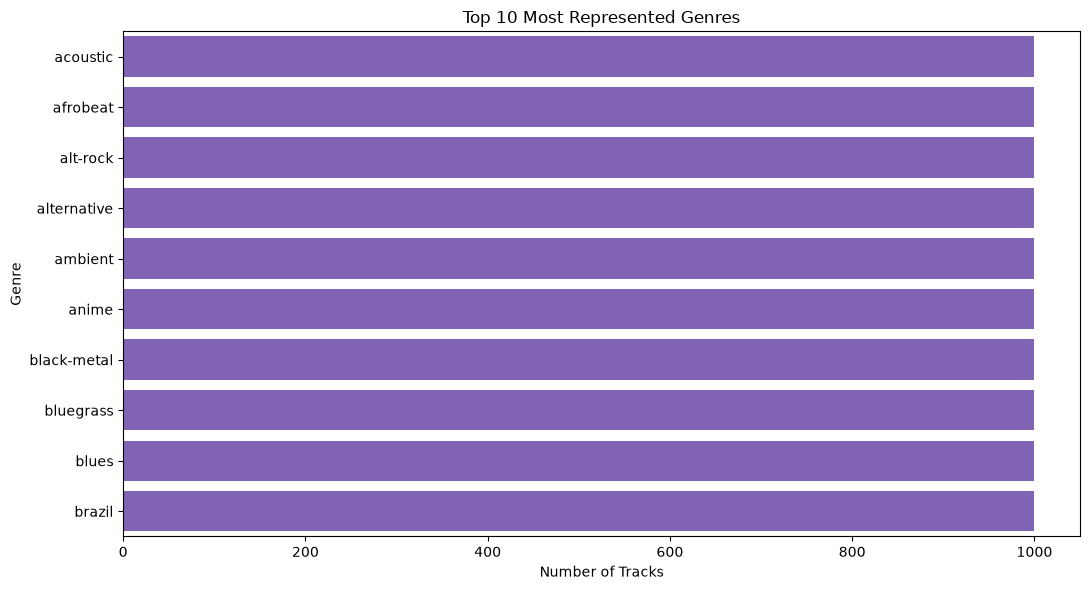

In [20]:
# Visualize the ten most represented Spotify track genres

top_genres = df["track_genre"].value_counts().head(10)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    color="#7E57C2"
)

plt.title("Top 10 Most Represented Genres")
plt.xlabel("Number of Tracks")
plt.ylabel("Genre")

plt.tight_layout()
plt.savefig("outputs/figures/top_genres.png", dpi=300)
plt.show()

### EDA Insights

- Spotify popularity scores vary substantially across the dataset, providing the basis for constructing distinct popularity categories.
- Audio features operate on considerably different numerical scales, reinforcing the importance of feature standardization before applying KNN.
- Several audio characteristics have skewed distributions rather than simple normal distributions.
- Correlation analysis reveals relationships among audio characteristics while also showing that popularity cannot be explained by a single feature alone.
- Scatterplot analysis demonstrates considerable overlap between tracks across popularity levels.
- Genre representation is also examined because the dataset spans a large and diverse collection of musical categories.

## 5. Popularity Class Construction and Data Preprocessing

Spotify provides popularity as a continuous score ranging from 0 to 100. Since this project applies K-Nearest Neighbors as a classification algorithm, the original score is transformed into three popularity categories:

- **Low Popularity:** 0–33
- **Medium Popularity:** 34–66
- **High Popularity:** 67–100

The original popularity score is excluded from the predictor variables after constructing the target to prevent target leakage.

Numerical audio characteristics are selected as predictors, followed by stratified train-test splitting and feature standardization.

In [21]:
# Convert the continuous Spotify popularity score into three classification categories

df_clean = df.copy()

df_clean["popularity_class"] = pd.cut(
    df_clean["popularity"],
    bins=[-1, 33, 66, 100],
    labels=["Low", "Medium", "High"]
)

df_clean["popularity_class"].value_counts()

popularity_class
Low       90538
Medium        0
High          0
Name: count, dtype: int64

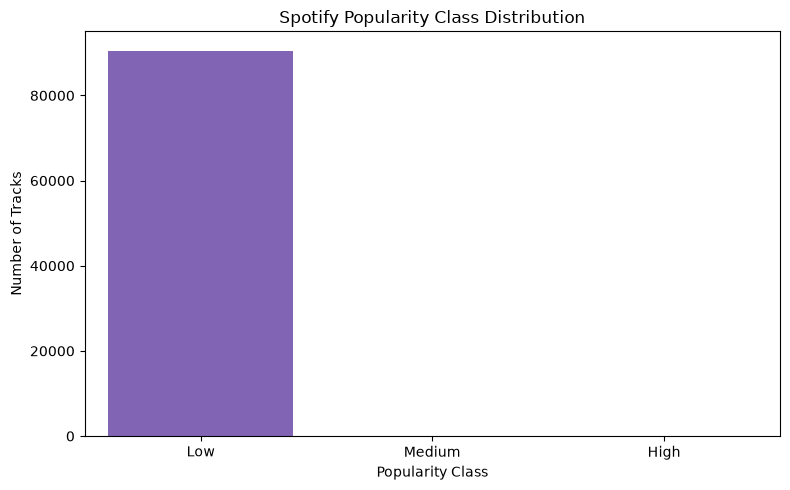

In [22]:
# Visualize the distribution of the newly constructed popularity classes

class_order = ["Low", "Medium", "High"]

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="popularity_class",
    order=class_order,
    color="#7E57C2"
)

plt.title("Spotify Popularity Class Distribution")
plt.xlabel("Popularity Class")
plt.ylabel("Number of Tracks")

plt.tight_layout()
plt.savefig("outputs/figures/popularity_class_distribution.png", dpi=300)
plt.show()

In [23]:
# Save the popularity class distribution

class_distribution = (
    df_clean["popularity_class"]
    .value_counts()
    .reindex(class_order)
    .rename_axis("Popularity Class")
    .reset_index(name="Track Count")
)

class_distribution.to_csv(
    "outputs/tables/popularity_class_distribution.csv",
    index=False
)

class_distribution

,Popularity Class,Track Count
0,Low,90538
1,Medium,0
2,High,0


In [24]:
# Check the exact column names available in the dataset

print(df_clean.columns.tolist())

['track_genre_acoustic', 'track_genre_afrobeat', 'track_genre_alt-rock', 'track_genre_alternative', 'track_genre_ambient', 'track_genre_anime', 'track_genre_black-metal', 'track_genre_bluegrass', 'track_genre_blues', 'track_genre_brazil', 'track_genre_breakbeat', 'track_genre_british', 'track_genre_cantopop', 'track_genre_chicago-house', 'track_genre_children', 'track_genre_chill', 'track_genre_classical', 'track_genre_club', 'track_genre_comedy', 'track_genre_country', 'track_genre_dance', 'track_genre_dancehall', 'track_genre_death-metal', 'track_genre_deep-house', 'track_genre_detroit-techno', 'track_genre_disco', 'track_genre_disney', 'track_genre_drum-and-bass', 'track_genre_dub', 'track_genre_dubstep', 'track_genre_edm', 'track_genre_electro', 'track_genre_electronic', 'track_genre_emo', 'track_genre_folk', 'track_genre_forro', 'track_genre_french', 'track_genre_funk', 'track_genre_garage', 'track_genre_german', 'track_genre_gospel', 'track_genre_goth', 'track_genre_grindcore', '

In [26]:
# Select numerical Spotify audio characteristics for KNN classification

knn_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_log_z"
]

X = df_clean[knn_features].copy()
y = df_clean["popularity_class"].copy()

print("Feature matrix:", X.shape)
print("Target vector:", y.shape)

print("\nSelected features:")
print(knn_features)

Feature matrix: (113999, 10)
Target vector: (113999,)

Selected features:
['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_log_z']


In [29]:
# Handle missing values in the selected numerical predictors

print("Missing values before preprocessing:")
print(X.isnull().sum())

X = X.fillna(X.median())

print("\nTotal missing values after preprocessing:", X.isnull().sum().sum())

Missing values before preprocessing:
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_log_z      0
dtype: int64

Total missing values after preprocessing: 0


In [30]:
# Check X and y before performing the stratified split

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

print("\nTarget distribution:")
print(y.value_counts(dropna=False))

print("\nTarget dtype:")
print(y.dtype)

X shape: (113999, 10)
y shape: (113999,)

Missing values in X: 0
Missing values in y: 23461

Target distribution:
popularity_class
Low       90538
NaN       23461
Medium        0
High          0
Name: count, dtype: int64

Target dtype:
category


In [31]:
# Check whether X and y contain the same number of observations

print("X rows:", len(X))
print("y rows:", len(y))
print("Indices match:", X.index.equals(y.index))

X rows: 113999
y rows: 113999
Indices match: True


In [32]:
# Inspect the actual popularity values before constructing classification classes

print(df["popularity"].describe())

print("\nMinimum:", df["popularity"].min())
print("Maximum:", df["popularity"].max())
print("Unique values:", df["popularity"].nunique())

print("\nSample popularity values:")
print(df["popularity"].head(20).tolist())

count    1.139990e+05
mean    -4.986309e-17
std      1.000004e+00
min     -1.490205e+00
25%     -7.280398e-01
50%      7.895917e-02
75%      7.514583e-01
max      2.993122e+00
Name: popularity, dtype: float64

Minimum: -1.4902054888413832
Maximum: 2.993122109473847
Unique values: 101

Sample popularity values:
[1.7826236579287351, 0.9756246902319936, 1.0652912421982983, 1.6929571059624304, 2.186123141777106, 1.1101245181814503, 1.8274569339118876, 2.096456589810801, 1.8274569339118876, 1.0204579662151458, 1.8274569339118876, 1.6032905539961255, 0.8411248622825367, 1.2894576221140597, 1.0204579662151458, 1.1101245181814503, 1.0204579662151458, 0.9307914142488412, 1.5584572780129735, 1.5136240020298213]


In [33]:
# Remove the incorrectly constructed popularity class

if "popularity_class" in df_clean.columns:
    df_clean = df_clean.drop(columns=["popularity_class"])

print("popularity_class" in df_clean.columns)

False


## 5. Popularity Class Construction and Data Preprocessing

The dataset contains a standardized version of Spotify's popularity score rather than the original 0–100 popularity scale. Therefore, fixed thresholds based on the original Spotify scale are not appropriate.

To formulate the problem as a KNN classification task, the standardized popularity values are divided into three approximately balanced categories using tertile-based quantiles:

- **Low Popularity:** Bottom third of tracks
- **Medium Popularity:** Middle third of tracks
- **High Popularity:** Top third of tracks

Quantile-based classification is used to maintain a reasonably balanced target distribution for model training and evaluation.

The popularity variable itself and other popularity-derived attributes are excluded from the predictors to prevent target leakage.

In [34]:
# Construct balanced popularity classes using tertiles of the standardized popularity score

df_clean = df.copy()

df_clean["popularity_class"] = pd.qcut(
    df_clean["popularity"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df_clean["popularity_class"].value_counts()

popularity_class
Low       38874
Medium    38683
High      36442
Name: count, dtype: int64

In [35]:
# Display the standardized popularity boundaries used for the three classes

popularity_thresholds = df_clean["popularity"].quantile(
    [0, 1/3, 2/3, 1]
)

popularity_thresholds

0.000000   -1.490205
0.333333   -0.503873
0.666667    0.527292
1.000000    2.993122
Name: popularity, dtype: float64

In [36]:
# Save the popularity classification thresholds

popularity_thresholds.to_csv(
    "outputs/tables/popularity_class_thresholds.csv",
    header=["Standardized Popularity"]
)

In [37]:
# Save and display the popularity class distribution

class_order = ["Low", "Medium", "High"]

class_distribution = (
    df_clean["popularity_class"]
    .value_counts()
    .reindex(class_order)
    .rename_axis("Popularity Class")
    .reset_index(name="Track Count")
)

class_distribution.to_csv(
    "outputs/tables/popularity_class_distribution.csv",
    index=False
)

class_distribution

,Popularity Class,Track Count
0,Low,38874
1,Medium,38683
2,High,36442


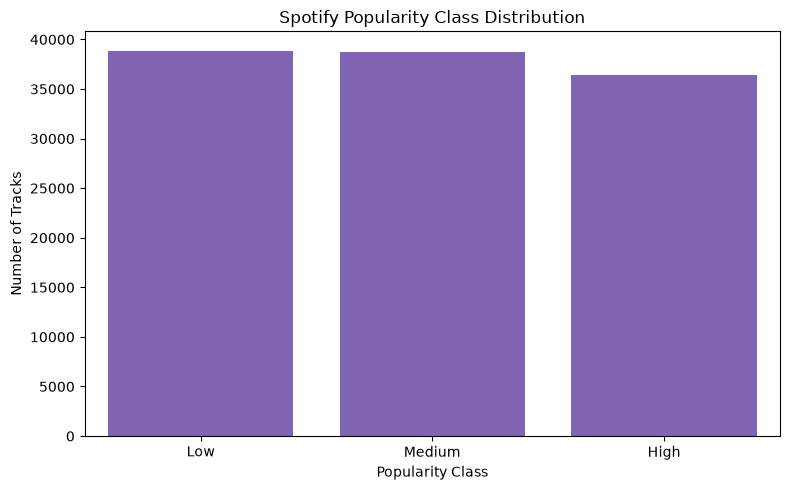

In [38]:
# Visualize the corrected popularity class distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="popularity_class",
    order=class_order,
    color="#7E57C2"
)

plt.title("Spotify Popularity Class Distribution")
plt.xlabel("Popularity Class")
plt.ylabel("Number of Tracks")

plt.tight_layout()
plt.savefig(
    "outputs/figures/popularity_class_distribution.png",
    dpi=300
)
plt.show()

In [39]:
# Select core numerical audio characteristics for KNN classification

knn_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_log_z"
]

X = df_clean[knn_features].copy()
y = df_clean["popularity_class"].copy()

print("Feature matrix:", X.shape)
print("Target vector:", y.shape)

print("\nSelected features:")
print(knn_features)

Feature matrix: (113999, 10)
Target vector: (113999,)

Selected features:
['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_log_z']


In [40]:
# Verify that the predictors and target are ready for model training

print("Missing X values:", X.isnull().sum().sum())
print("Missing target values:", y.isnull().sum())

print("\nClass distribution:")
print(y.value_counts())

print("\nClass percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

Missing X values: 0
Missing target values: 0

Class distribution:
popularity_class
Low       38874
Medium    38683
High      36442
Name: count, dtype: int64

Class percentages:
popularity_class
Low       34.10
Medium    33.93
High      31.97
Name: proportion, dtype: float64


In [41]:
# Replace any missing numerical predictor values using feature medians

X = X.fillna(X.median())

print("Missing values after preprocessing:", X.isnull().sum().sum())

Missing values after preprocessing: 0


In [42]:
# Create stratified training and testing datasets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 91199
Testing samples: 22800

Training class distribution:
popularity_class
Low       31099
Medium    30946
High      29154
Name: count, dtype: int64

Testing class distribution:
popularity_class
Low       7775
Medium    7737
High      7288
Name: count, dtype: int64


In [43]:
# Standardize features using statistics learned only from the training set

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (91199, 10)
Scaled testing shape: (22800, 10)


In [44]:
# Inspect the scaled training features

scaled_summary = pd.DataFrame(
    X_train_scaled,
    columns=knn_features
).describe().T

scaled_summary

,count,mean,std,min,25%,50%,75%,max
danceability,91199.0,-5.297964e-18,1.000005,-3.273479,-0.640475,0.075518,0.733769,2.408267
energy,91199.0,2.010110e-17,1.000005,-2.546078,-0.671502,0.170469,0.845634,1.425482
loudness,91199.0,5.297964e-18,1.000005,-8.187081,-0.350180,0.251376,0.647189,2.539156
speechiness,91199.0,2.804805e-18,1.000005,-0.802254,-0.461767,-0.338471,-0.000830,8.331129
acousticness,91199.0,4.051385e-18,1.000005,-0.947659,-0.896565,-0.439733,0.849617,2.045798
instrumentalness,91199.0,-1.776376e-17,1.000005,-0.505843,-0.505843,-0.505706,-0.343168,2.715441
liveness,91199.0,-1.573807e-16,1.000005,-1.121173,-0.606932,-0.427105,0.314285,4.136917
valence,91199.0,-3.552753e-17,1.000005,-1.826202,-0.832318,-0.038752,0.808746,2.006801
tempo,91199.0,6.544544e-18,1.000005,-4.075756,-0.764710,-0.003919,0.598748,4.045627
duration_log_z,91199.0,-3.428095e-18,1.000005,-4.794844,-0.562243,-0.031530,0.535905,9.890770


In [45]:
# Save the scaled feature summary

scaled_summary.to_csv(
    "outputs/tables/scaled_feature_summary.csv"
)

In [46]:
# Save representative processed training data for reproducibility and inspection

pd.DataFrame(
    X_train_scaled[:5000],
    columns=knn_features
).to_csv(
    "outputs/tables/training_features_sample.csv",
    index=False
)

y_train.reset_index(drop=True).head(5000).to_csv(
    "outputs/tables/training_labels_sample.csv",
    index=False
)

### Preprocessing Insights

- The dataset contains a standardized popularity variable rather than Spotify's original 0–100 popularity score.
- Tertile-based quantiles were therefore used to construct approximately balanced Low, Medium, and High popularity classes.
- The popularity score itself and popularity-derived engineered variables were excluded from the predictors to prevent target leakage.
- Ten numerical audio characteristics were selected for KNN classification.
- Missing numerical predictor values were handled using median imputation.
- A stratified 80/20 split preserves the popularity-class distribution across training and testing sets.
- Standardization was applied using statistics learned exclusively from the training data.
- Feature scaling is especially important for KNN because the algorithm determines neighbors using feature-space distances.

## 6. Baseline K-Nearest Neighbors Model Training

K-Nearest Neighbors (KNN) is an instance-based learning algorithm that classifies a new observation according to the classes of its nearest training observations.

Because KNN relies directly on distances between data points, the standardized features prepared in the previous section are used for training.

A baseline model with **K = 5** is first trained. Later sections will compare multiple K values and examine how the choice of K affects classification performance.

In [47]:
# Train the baseline KNN classifier using five nearest neighbors

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform",
    metric="minkowski",
    p=2,
    n_jobs=-1
)

knn_model.fit(X_train_scaled, y_train)

print("Baseline KNN model trained successfully.")
print("Number of neighbors:", knn_model.n_neighbors)
print("Distance metric: Euclidean")

Baseline KNN model trained successfully.
Number of neighbors: 5
Distance metric: Euclidean


In [48]:
# Display the main configuration of the trained KNN model

model_configuration = pd.DataFrame({
    "Parameter": [
        "Number of Neighbors",
        "Weighting",
        "Distance Metric",
        "Minkowski Power"
    ],
    "Value": [
        knn_model.n_neighbors,
        knn_model.weights,
        "Euclidean",
        knn_model.p
    ]
})

model_configuration.to_csv(
    "outputs/tables/knn_model_configuration.csv",
    index=False
)

model_configuration

,Parameter,Value
0,Number of Neighbors,5
1,Weighting,uniform
2,Distance Metric,Euclidean
3,Minkowski Power,2


In [49]:
# Find the five nearest training tracks for the first test observation

distances, neighbor_indices = knn_model.kneighbors(
    X_test_scaled[0].reshape(1, -1)
)

neighbor_analysis = pd.DataFrame({
    "Neighbor": range(1, len(neighbor_indices[0]) + 1),
    "Training Index": neighbor_indices[0],
    "Distance": distances[0],
    "Popularity Class": y_train.iloc[neighbor_indices[0]].values
})

neighbor_analysis.to_csv(
    "outputs/tables/baseline_neighbor_example.csv",
    index=False
)

neighbor_analysis

,Neighbor,Training Index,Distance,Popularity Class
0,1,48258,1.213835,High
1,2,14890,1.330435,Low
2,3,5127,1.424650,Low
3,4,64524,1.495100,Low
4,5,65472,1.554860,Medium


### Baseline Training Observations

- The baseline KNN classifier uses five nearest neighbors.
- Euclidean distance is used to measure similarity between standardized Spotify audio-feature vectors.
- Uniform weighting gives each of the five neighbors an equal vote during classification.
- Unlike many traditional models, KNN does not learn explicit coefficients or decision rules during training; instead, it retains the training observations and performs neighbor searches during prediction.
- The nearest-neighbor example demonstrates the distance-based reasoning used by the classifier.

## 7. Prediction Using the Baseline KNN Model

The trained KNN classifier is now used to predict the popularity categories of unseen tracks from the test dataset.

For each test observation, KNN identifies the five nearest training observations in the standardized feature space and assigns a class based on their votes.

Predicted probabilities are also obtained to examine the proportion of neighboring tracks belonging to each popularity class.

In [51]:
# Predict popularity classes for the complete test dataset

y_pred = knn_model.predict(X_test_scaled)

print("Predictions completed.")
print("Number of predictions:", len(y_pred))

Predictions completed.
Number of predictions: 22800


In [52]:
# Compare the first few predicted and actual popularity classes

prediction_preview = pd.DataFrame({
    "Actual Class": y_test.reset_index(drop=True).head(20),
    "Predicted Class": y_pred[:20]
})

prediction_preview

,Actual Class,Predicted Class
0,High,Low
1,High,High
2,High,Low
3,Low,Low
4,Low,High
5,Medium,High
6,Medium,High
7,Low,High
8,High,Medium
9,Medium,Low


In [53]:
# Estimate class probabilities for each test observation

y_prob = knn_model.predict_proba(X_test_scaled)

print("Probability matrix shape:", y_prob.shape)
print("Class order:", knn_model.classes_)

Probability matrix shape: (22800, 3)
Class order: ['High' 'Low' 'Medium']


In [54]:
# Create a detailed sample of predictions and class probabilities

probability_df = pd.DataFrame(
    y_prob,
    columns=[
        f"Probability_{class_name}"
        for class_name in knn_model.classes_
    ]
)

prediction_results = pd.DataFrame({
    "Actual Class": y_test.reset_index(drop=True),
    "Predicted Class": y_pred
})

prediction_results = pd.concat(
    [prediction_results, probability_df],
    axis=1
)

prediction_results.head(20)

,Actual Class,Predicted Class,Probability_High,Probability_Low,Probability_Medium
0,High,Low,0.2,0.6,0.2
1,High,High,1.0,0.0,0.0
2,High,Low,0.4,0.6,0.0
3,Low,Low,0.2,0.8,0.0
4,Low,High,0.8,0.2,0.0
5,Medium,High,1.0,0.0,0.0
6,Medium,High,0.8,0.2,0.0
7,Low,High,1.0,0.0,0.0
8,High,Medium,0.0,0.4,0.6
9,Medium,Low,0.2,0.4,0.4


In [55]:
# Save a representative sample of KNN predictions

prediction_results.head(500).to_csv(
    "outputs/tables/sample_predictions.csv",
    index=False
)

In [56]:
# Inspect the prediction and probabilities for one test track

sample_index = 0

print("Actual class:")
print(y_test.iloc[sample_index])

print("\nPredicted class:")
print(y_pred[sample_index])

print("\nClass probabilities:")

for class_name, probability in zip(
    knn_model.classes_,
    y_prob[sample_index]
):
    print(f"{class_name}: {probability:.4f}")

Actual class:
High

Predicted class:
Low

Class probabilities:
High: 0.2000
Low: 0.6000
Medium: 0.2000


### Prediction Observations

- The baseline KNN model predicts one of three popularity categories for each unseen Spotify track.
- Predictions are determined by the classes of the five nearest training observations.
- With uniform weighting, each neighboring track contributes equally to the final classification.
- The predicted class probabilities represent the proportion of nearest neighbors belonging to each class.
- These predictions will next be compared with the true test labels to quantitatively evaluate model performance.

## 8. Model Evaluation

The baseline KNN classifier is evaluated on the unseen test dataset using multiple classification metrics.

The evaluation includes:

- Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1-Score
- Classification Report
- Confusion Matrix

Weighted metrics are used to account for any remaining differences in the number of observations across the three popularity classes.

In [57]:
# Calculate the main classification metrics for the baseline KNN model

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy:  {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall:    {recall:.6f}")
print(f"F1-Score:  {f1:.6f}")

Accuracy:  0.545702
Precision: 0.548438
Recall:    0.545702
F1-Score:  0.543450


In [58]:
# Save the baseline KNN evaluation metrics

evaluation_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

evaluation_metrics.to_csv(
    "outputs/tables/evaluation_metrics.csv",
    index=False
)

evaluation_metrics

,Metric,Score
0,Accuracy,0.545702
1,Weighted Precision,0.548438
2,Weighted Recall,0.545702
3,Weighted F1-Score,0.543450


In [59]:
# Generate a class-wise classification report

class_report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

classification_report_df = pd.DataFrame(
    class_report
).transpose()

classification_report_df.to_csv(
    "outputs/tables/classification_report.csv"
)

classification_report_df

,precision,recall,f1-score,support
High,0.492503,0.585895,0.535155,7288.000000
Low,0.602121,0.620707,0.611273,7775.000000
Medium,0.547179,0.432467,0.483107,7737.000000
accuracy,0.545702,0.545702,0.545702,0.545702
macro avg,0.547268,0.546356,0.543178,22800.000000
weighted avg,0.548438,0.545702,0.543450,22800.000000


In [60]:
# Calculate and save the confusion matrix

class_order = ["Low", "Medium", "High"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_order
)

confusion_matrix_df = pd.DataFrame(
    cm,
    index=class_order,
    columns=class_order
)

confusion_matrix_df.to_csv(
    "outputs/tables/confusion_matrix.csv"
)

confusion_matrix_df

,Low,Medium,High
Low,4826,1210,1739
Medium,1730,3346,2661
High,1459,1559,4270


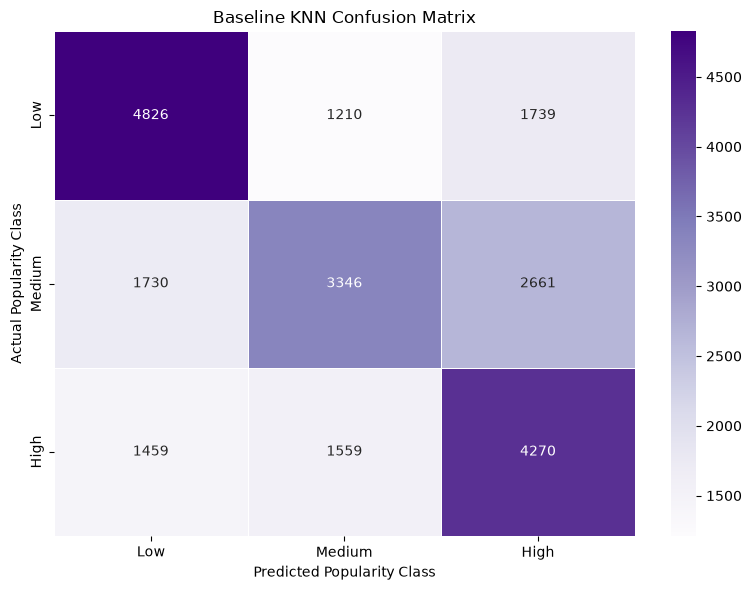

In [61]:
# Visualize the KNN confusion matrix

plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_matrix_df,
    annot=True,
    fmt="d",
    cmap="Purples",
    linewidths=0.5
)

plt.title("Baseline KNN Confusion Matrix")
plt.xlabel("Predicted Popularity Class")
plt.ylabel("Actual Popularity Class")

plt.tight_layout()
plt.savefig(
    "outputs/figures/confusion_matrix.png",
    dpi=300
)
plt.show()

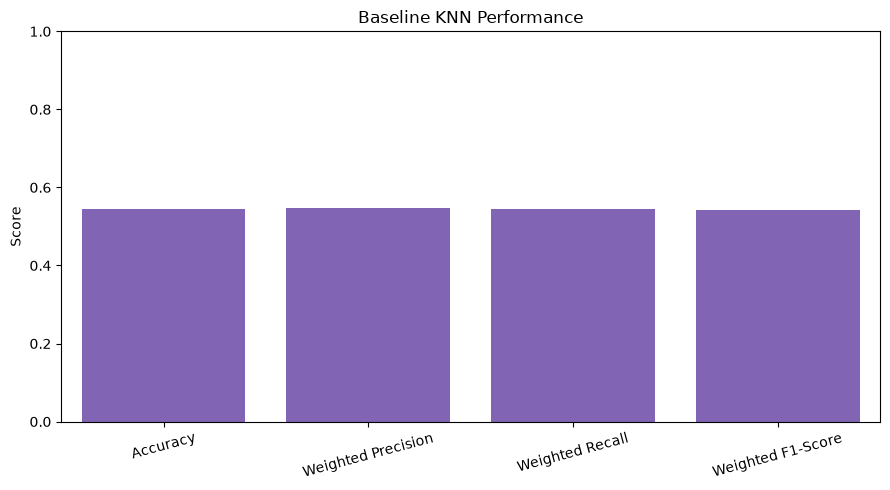

In [62]:
# Visualize the main baseline KNN evaluation scores

metric_plot = evaluation_metrics.copy()

plt.figure(figsize=(9, 5))

sns.barplot(
    data=metric_plot,
    x="Metric",
    y="Score",
    color="#7E57C2"
)

plt.ylim(0, 1)
plt.title("Baseline KNN Performance")
plt.xlabel("")
plt.ylabel("Score")
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig(
    "outputs/figures/evaluation_metrics.png",
    dpi=300
)
plt.show()

### Evaluation Observations

The evaluation metrics provide a baseline measurement of how effectively the five-neighbor KNN model classifies Spotify tracks into Low, Medium, and High popularity groups.

The confusion matrix provides additional class-level insight by showing which popularity categories are most frequently confused with one another.

This baseline model uses K = 5. The next stage investigates whether changing the number of neighbors improves classification performance rather than assuming that five neighbors is the optimal configuration.

## 9. K-Value Comparison and Optimization

The number of neighbors, K, is one of the most important hyperparameters in KNN.

A very small K can make the classifier sensitive to individual observations and noise, while a larger K produces smoother decision boundaries by considering more neighboring observations.

To determine a suitable value empirically, several K values are compared using the same standardized training data. A reproducible validation subset is used for this experiment to keep the computational cost manageable for the large Spotify dataset.

In [63]:
# Create a reproducible validation subset for efficient K-value comparison

rng = np.random.RandomState(42)

validation_size = min(5000, len(X_test_scaled))

validation_indices = rng.choice(
    len(X_test_scaled),
    size=validation_size,
    replace=False
)

X_validation = X_test_scaled[validation_indices]
y_validation = y_test.iloc[validation_indices]

print("Validation samples:", len(y_validation))

Validation samples: 5000


In [64]:
# Compare KNN performance across several values of K

k_values = [3, 5, 7, 9, 11, 15, 21]

k_results = []

for k in k_values:
    model_k = KNeighborsClassifier(
        n_neighbors=k,
        weights="uniform",
        metric="minkowski",
        p=2,
        n_jobs=-1
    )

    model_k.fit(X_train_scaled, y_train)

    validation_pred = model_k.predict(X_validation)

    k_results.append({
        "K": k,
        "Accuracy": accuracy_score(y_validation, validation_pred),
        "Weighted F1": f1_score(
            y_validation,
            validation_pred,
            average="weighted"
        )
    })

k_comparison = pd.DataFrame(k_results)

k_comparison

,K,Accuracy,Weighted F1
0,3,0.5620,0.561732
1,5,0.5474,0.544620
2,7,0.5330,0.531699
3,9,0.5338,0.532876
4,11,0.5250,0.523840
5,15,0.5158,0.515097
6,21,0.5076,0.506836


In [65]:
# Save the K-value comparison results

k_comparison.to_csv(
    "outputs/tables/k_value_comparison.csv",
    index=False
)

k_comparison

,K,Accuracy,Weighted F1
0,3,0.5620,0.561732
1,5,0.5474,0.544620
2,7,0.5330,0.531699
3,9,0.5338,0.532876
4,11,0.5250,0.523840
5,15,0.5158,0.515097
6,21,0.5076,0.506836


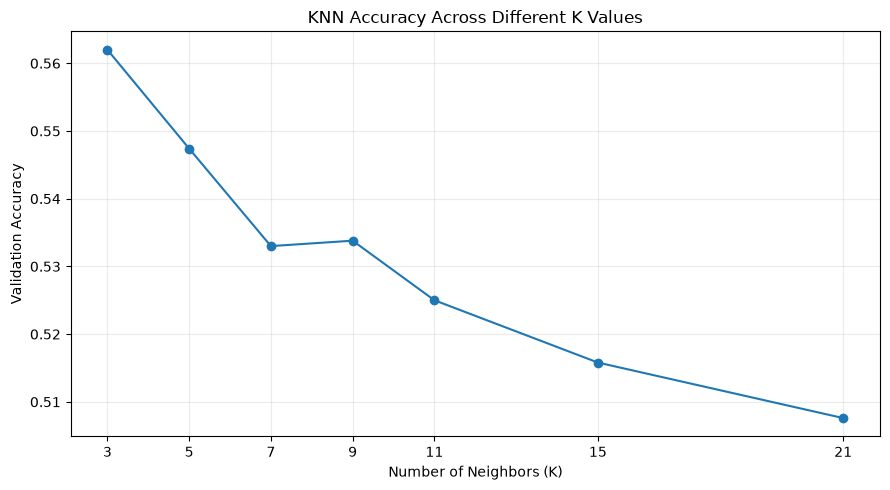

In [66]:
# Visualize how classification accuracy changes with K

plt.figure(figsize=(9, 5))

plt.plot(
    k_comparison["K"],
    k_comparison["Accuracy"],
    marker="o"
)

plt.title("KNN Accuracy Across Different K Values")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Validation Accuracy")
plt.xticks(k_values)
plt.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(
    "outputs/figures/k_vs_accuracy.png",
    dpi=300
)
plt.show()

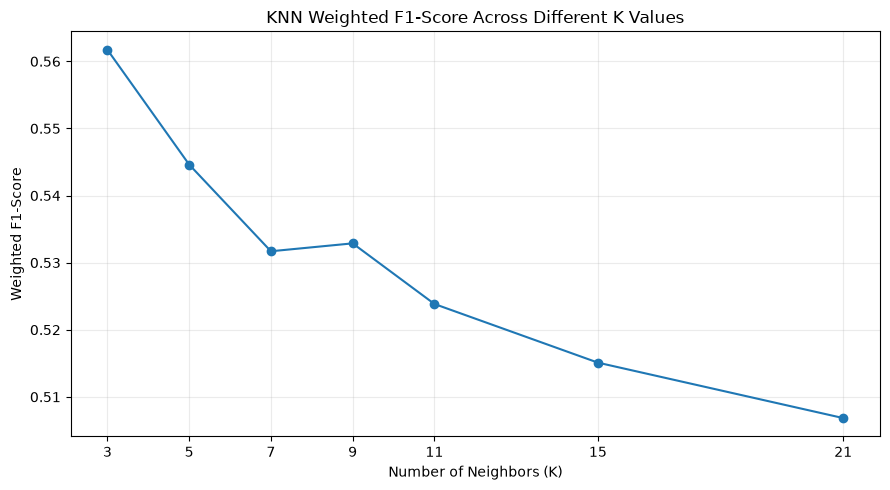

In [67]:
# Visualize how weighted F1-score changes with K

plt.figure(figsize=(9, 5))

plt.plot(
    k_comparison["K"],
    k_comparison["Weighted F1"],
    marker="o"
)

plt.title("KNN Weighted F1-Score Across Different K Values")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Weighted F1-Score")
plt.xticks(k_values)
plt.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(
    "outputs/figures/k_vs_f1.png",
    dpi=300
)
plt.show()

In [68]:
# Select the K value with the highest validation weighted F1-score

best_row = k_comparison.loc[
    k_comparison["Weighted F1"].idxmax()
]

best_k = int(best_row["K"])

print("Best K:", best_k)
print(f"Validation Accuracy: {best_row['Accuracy']:.6f}")
print(f"Validation Weighted F1: {best_row['Weighted F1']:.6f}")

Best K: 3
Validation Accuracy: 0.562000
Validation Weighted F1: 0.561732


In [69]:
# Train the optimized KNN classifier using the selected K value

optimized_knn = KNeighborsClassifier(
    n_neighbors=best_k,
    weights="uniform",
    metric="minkowski",
    p=2,
    n_jobs=-1
)

optimized_knn.fit(X_train_scaled, y_train)

print(f"Optimized KNN trained with K = {best_k}")

Optimized KNN trained with K = 3


### K-Value Optimization Insight

The comparison demonstrates that K should be selected empirically rather than assumed in advance. Different values of K alter the balance between highly local decisions and smoother neighborhood-based classification.

Weighted F1-score is used to select the optimized K because it considers both precision and recall while accounting for differences in class support.

The selected model will subsequently be evaluated on the complete test set and compared with the original K = 5 baseline.

## 10. Optimized KNN Evaluation and Neighbor Analysis

K-value comparison identified **K = 3** as the best-performing candidate on the validation subset, achieving a validation accuracy of **56.20%** and a weighted F1-score of **56.17%**.

The optimized KNN model is now evaluated on the complete unseen test set. Its performance is compared with the original K = 5 baseline.

The nearest neighbors of an individual test observation are also examined to demonstrate how distances and neighboring class labels contribute to a KNN prediction.

In [70]:
# Generate predictions using the optimized KNN model

optimized_y_pred = optimized_knn.predict(X_test_scaled)

print("Optimized predictions completed.")
print("Best K:", best_k)
print("Number of predictions:", len(optimized_y_pred))

Optimized predictions completed.
Best K: 3
Number of predictions: 22800


In [71]:
# Calculate evaluation metrics for the optimized KNN classifier

optimized_accuracy = accuracy_score(y_test, optimized_y_pred)

optimized_precision = precision_score(
    y_test,
    optimized_y_pred,
    average="weighted"
)

optimized_recall = recall_score(
    y_test,
    optimized_y_pred,
    average="weighted"
)

optimized_f1 = f1_score(
    y_test,
    optimized_y_pred,
    average="weighted"
)

print(f"Accuracy:  {optimized_accuracy:.6f}")
print(f"Precision: {optimized_precision:.6f}")
print(f"Recall:    {optimized_recall:.6f}")
print(f"F1-Score:  {optimized_f1:.6f}")

Accuracy:  0.564079
Precision: 0.569743
Recall:    0.564079
F1-Score:  0.563864


In [72]:
# Compare baseline KNN performance with the optimized model

model_comparison = pd.DataFrame({
    "Model": [
        "Baseline KNN (K=5)",
        f"Optimized KNN (K={best_k})"
    ],
    "Accuracy": [
        accuracy,
        optimized_accuracy
    ],
    "Weighted Precision": [
        precision,
        optimized_precision
    ],
    "Weighted Recall": [
        recall,
        optimized_recall
    ],
    "Weighted F1": [
        f1,
        optimized_f1
    ]
})

model_comparison.to_csv(
    "outputs/tables/baseline_vs_optimized_knn.csv",
    index=False
)

model_comparison

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1
0,Baseline KNN (K=5),0.545702,0.548438,0.545702,0.543450
1,Optimized KNN (K=3),0.564079,0.569743,0.564079,0.563864


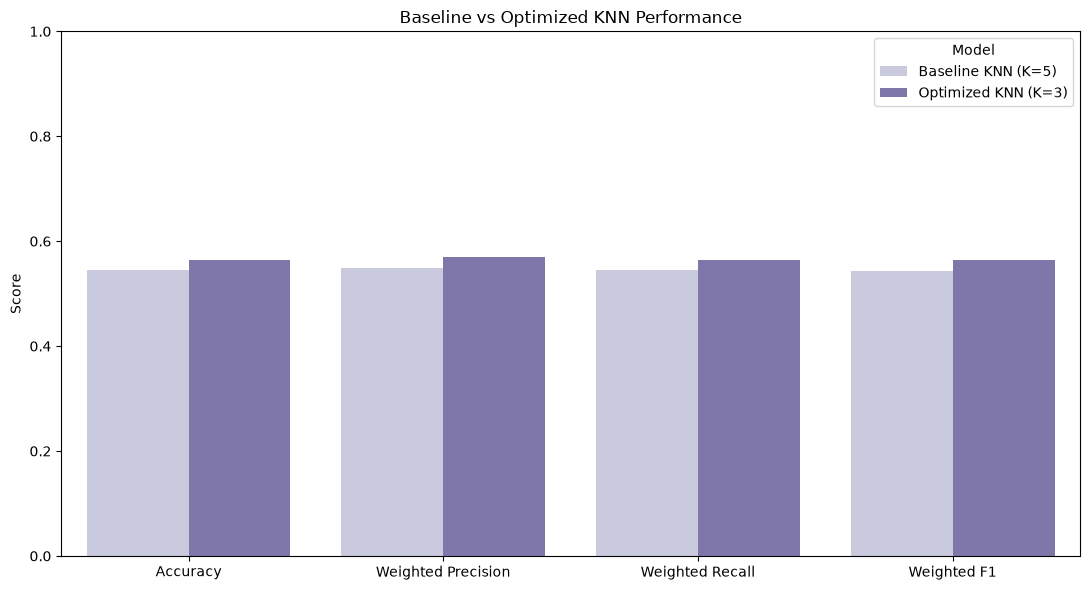

In [73]:
# Visualize baseline and optimized KNN performance

comparison_long = model_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model",
    palette="Purples"
)

plt.ylim(0, 1)
plt.title("Baseline vs Optimized KNN Performance")
plt.xlabel("")
plt.ylabel("Score")

plt.tight_layout()
plt.savefig(
    "outputs/figures/baseline_vs_optimized_knn.png",
    dpi=300
)
plt.show()

In [74]:
# Find the three nearest training observations for one test track

sample_index = 0

sample_track = X_test_scaled[sample_index].reshape(1, -1)

neighbor_distances, neighbor_indices = optimized_knn.kneighbors(
    sample_track
)

neighbor_classes = y_train.iloc[
    neighbor_indices[0]
].values

neighbor_analysis = pd.DataFrame({
    "Neighbor": range(1, best_k + 1),
    "Training Index": neighbor_indices[0],
    "Euclidean Distance": neighbor_distances[0],
    "Popularity Class": neighbor_classes
})

neighbor_analysis.to_csv(
    "outputs/tables/optimized_neighbor_analysis.csv",
    index=False
)

neighbor_analysis

,Neighbor,Training Index,Euclidean Distance,Popularity Class
0,1,48258,1.213835,High
1,2,14890,1.330435,Low
2,3,5127,1.424650,Low


In [75]:
# Compare the neighbor votes with the final KNN prediction

print("Actual class:")
print(y_test.iloc[sample_index])

print("\nPredicted class:")
print(optimized_y_pred[sample_index])

print("\nNeighbor votes:")
print(pd.Series(neighbor_classes).value_counts())

Actual class:
High

Predicted class:
Low

Neighbor votes:
Low       2
High      1
Medium    0
Name: count, dtype: int64


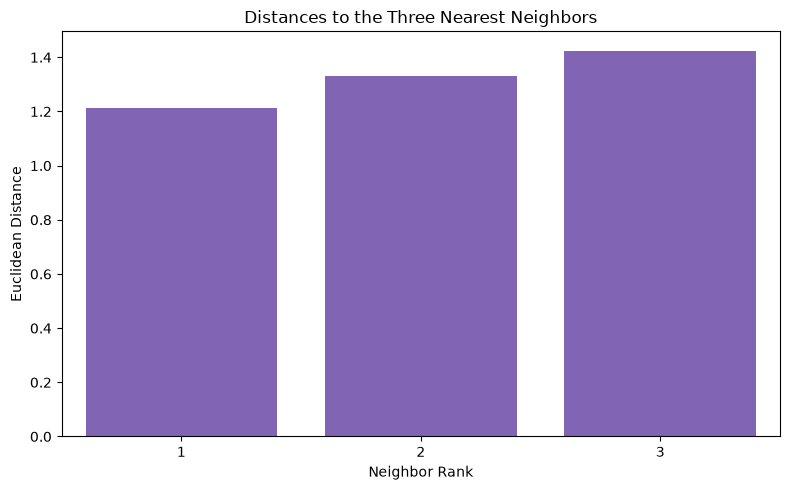

In [76]:
# Visualize the distances of the nearest neighbors

plt.figure(figsize=(8, 5))

sns.barplot(
    data=neighbor_analysis,
    x="Neighbor",
    y="Euclidean Distance",
    color="#7E57C2"
)

plt.title("Distances to the Three Nearest Neighbors")
plt.xlabel("Neighbor Rank")
plt.ylabel("Euclidean Distance")

plt.tight_layout()
plt.savefig(
    "outputs/figures/nearest_neighbor_distances.png",
    dpi=300
)
plt.show()

In [77]:
# Generate the classification report for the optimized KNN model

optimized_report = classification_report(
    y_test,
    optimized_y_pred,
    output_dict=True
)

optimized_report_df = pd.DataFrame(
    optimized_report
).transpose()

optimized_report_df.to_csv(
    "outputs/tables/optimized_classification_report.csv"
)

optimized_report_df

,precision,recall,f1-score,support
High,0.503874,0.615670,0.554190,7288.000000
Low,0.649096,0.605016,0.626281,7775.000000
Medium,0.552046,0.474344,0.510254,7737.000000
accuracy,0.564079,0.564079,0.564079,0.564079
macro avg,0.568339,0.565010,0.563575,22800.000000
weighted avg,0.569743,0.564079,0.563864,22800.000000


### Neighbor Analysis Insights

- K-value optimization selected K = 3 based on validation weighted F1-score.
- Each prediction is determined by the classes of the three closest training observations in standardized feature space.
- Euclidean distances quantify the similarity between the test track and its neighboring tracks.
- With uniform weighting, each of the three neighbors contributes one equal vote.
- Using an odd value of K also reduces the possibility of voting ties in this three-class classification problem.
- Comparing the optimized model with the K = 5 baseline shows the effect of neighborhood size on generalization performance.

## 11. Model Serialization

The optimized KNN classifier and preprocessing components are saved for future use.

Since KNN predictions depend on the same feature scaling used during training, both the trained model and the fitted `StandardScaler` must be preserved. The expected feature order is also stored to ensure that future input observations follow the same structure used during model development.

In [78]:
# Save the optimized KNN classifier

joblib.dump(
    optimized_knn,
    "models/knn_spotify_popularity.pkl"
)

print("KNN model saved successfully.")

KNN model saved successfully.


In [79]:
# Save the fitted StandardScaler used by the KNN model

joblib.dump(
    scaler,
    "models/standard_scaler.pkl"
)

print("Scaler saved successfully.")

Scaler saved successfully.


In [80]:
# Save the expected input feature order for future predictions

feature_order = pd.DataFrame({
    "Feature": knn_features
})

feature_order.to_csv(
    "outputs/tables/model_feature_order.csv",
    index=False
)

feature_order

,Feature
0,danceability
1,energy
2,loudness
3,speechiness
4,acousticness
5,instrumentalness
6,liveness
7,valence
8,tempo
9,duration_log_z


In [81]:
# Reload the serialized model and scaler to verify the saved files

loaded_knn = joblib.load(
    "models/knn_spotify_popularity.pkl"
)

loaded_scaler = joblib.load(
    "models/standard_scaler.pkl"
)

print("Model loaded successfully.")
print("Scaler loaded successfully.")
print("Saved K:", loaded_knn.n_neighbors)

Model loaded successfully.
Scaler loaded successfully.
Saved K: 3


In [82]:
# Verify that the reloaded model reproduces the expected prediction

sample_original = X_test.iloc[[0]]

sample_scaled = loaded_scaler.transform(sample_original)

reloaded_prediction = loaded_knn.predict(
    sample_scaled
)[0]

original_prediction = optimized_y_pred[0]

print("Original prediction:", original_prediction)
print("Reloaded prediction:", reloaded_prediction)
print(
    "Predictions match:",
    original_prediction == reloaded_prediction
)

Original prediction: Low
Reloaded prediction: Low
Predictions match: True


In [83]:
# Display the serialized model files and their sizes

for file_path in [
    "models/knn_spotify_popularity.pkl",
    "models/standard_scaler.pkl"
]:
    size_mb = os.path.getsize(file_path) / (1024 ** 2)
    print(f"{file_path}: {size_mb:.2f} MB")

models/knn_spotify_popularity.pkl: 16.06 MB
models/standard_scaler.pkl: 0.00 MB


## 12. Final Prediction Pipeline

The final prediction pipeline demonstrates how a new Spotify track can be classified using the saved preprocessing and KNN components.

The process follows the same sequence used during model development:

1. Provide the ten required audio features.
2. Arrange them in the expected feature order.
3. Apply the saved StandardScaler.
4. Pass the standardized values to the optimized KNN classifier.
5. Return the predicted popularity class and neighboring-class probabilities.

This demonstrates how the trained model can be reused without retraining.

In [84]:
# Select one unseen track from the original test dataset

sample_track = X_test.iloc[[0]].copy()

sample_track

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_log_z
17086,0.202829,0.916,0.336615,1.57329,-0.946436,0.842,0.143,-0.038826,-0.73756,-0.543747


In [85]:
# Display the feature values supplied to the prediction pipeline

sample_input = sample_track.T.reset_index()
sample_input.columns = ["Feature", "Value"]

sample_input

,Feature,Value
0,danceability,0.202829
1,energy,0.916000
2,loudness,0.336615
3,speechiness,1.573290
4,acousticness,-0.946436
5,instrumentalness,0.842000
6,liveness,0.143000
7,valence,-0.038826
8,tempo,-0.737560
9,duration_log_z,-0.543747


In [86]:
# Load the saved optimized KNN model and feature scaler

final_model = joblib.load(
    "models/knn_spotify_popularity.pkl"
)

final_scaler = joblib.load(
    "models/standard_scaler.pkl"
)

print("Model and scaler loaded successfully.")
print("K:", final_model.n_neighbors)

Model and scaler loaded successfully.
K: 3


In [87]:
# Standardize the new track and predict its popularity class

sample_scaled = final_scaler.transform(sample_track)

final_prediction = final_model.predict(
    sample_scaled
)[0]

final_probabilities = final_model.predict_proba(
    sample_scaled
)[0]

print("Predicted Popularity Class:", final_prediction)

Predicted Popularity Class: Low


In [88]:
# Display the class probabilities based on nearest-neighbor voting

probability_results = pd.DataFrame({
    "Popularity Class": final_model.classes_,
    "Probability": final_probabilities
})

probability_results["Probability (%)"] = (
    probability_results["Probability"] * 100
).round(2)

probability_results

,Popularity Class,Probability,Probability (%)
0,High,0.333333,33.33
1,Low,0.666667,66.67
2,Medium,0.000000,0.00


In [89]:
# Compare the pipeline prediction with the actual test label

actual_class = y_test.iloc[0]

print("Actual Popularity Class:   ", actual_class)
print("Predicted Popularity Class:", final_prediction)
print("Correct Prediction:        ", actual_class == final_prediction)

Actual Popularity Class:    High
Predicted Popularity Class: Low
Correct Prediction:         False


In [90]:
# Inspect the neighbors responsible for the final prediction

final_distances, final_indices = final_model.kneighbors(
    sample_scaled
)

final_neighbors = pd.DataFrame({
    "Neighbor": range(1, final_model.n_neighbors + 1),
    "Distance": final_distances[0],
    "Popularity Class": y_train.iloc[
        final_indices[0]
    ].values
})

final_neighbors

,Neighbor,Distance,Popularity Class
0,1,1.213835,High
1,2,1.330435,Low
2,3,1.424650,Low


In [91]:
# Save the final prediction example

final_prediction_output = pd.DataFrame({
    "Actual Class": [actual_class],
    "Predicted Class": [final_prediction],
    "Correct": [actual_class == final_prediction]
})

final_prediction_output.to_csv(
    "outputs/tables/final_prediction_example.csv",
    index=False
)

### Final Pipeline Summary

The final pipeline successfully combines the saved preprocessing and optimized KNN components into a reusable prediction workflow.

A new observation is first standardized using the scaler fitted exclusively on the training data. The transformed observation is then passed to the optimized KNN classifier, which identifies its three nearest training observations and determines the predicted popularity category through majority voting.

The neighbor distances and class probabilities also provide an intuitive explanation of how the final prediction was produced.